<a href="https://colab.research.google.com/github/galangsandyakbar/KarirNex/blob/Tugas/GALANG_SANDY_A_TUGAS_DAY_2_KARIRNEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP 1: IMPORT LIBRARY

In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

pd.set_option('display.max_columns', None)

# STEP 2: LOAD DATASET

In [54]:
# Load dataset
df_raw = pd.read_csv('Data FMCG_BT Data Analyst - Messy.csv', sep= ';')

# Preview data
df_raw.head()

,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status,Unnamed: 15
0,01/01/2025,P00001,Minyak Goreng,Makanan,18000.0,1.0,NaN,0.15,20000.0,NaN,Shinta,Malang,Toko_Oren_Online,5.0,Returned,NaN
1,01/01/2025,P00002,Kopi,Makanan,25000.0,3.0,NaN,0.15,22000.0,NaN,Eli,Makassar,Offline,4.0,Failed,NaN
2,01/01/2025,P00003,Deterjen,PEMBERSIH,10000.0,3.0,NaN,0.15,25000.0,NaN,Eka,Medan,Offline,1.0,Pending,NaN
3,01/01/2025,P00004,Minyak Goreng,makanan,18000.0,1.0,NaN,0.15,20000.0,NaN,Zenia,Surabaya,Online - Toko Oren,3.0,Pending,NaN
4,01/01/2025,P00005,Pasta Gigi,Perawatan,15000.0,3.0,NaN,0.15,12000.0,NaN,Dicky,Bogor,Online - Toko Oren,1.0,Returned,NaN


# STEP 3: IDENTIFIKASI MASALAH DATA

## DATA SET OVERVIEW

In [55]:
df_raw.shape

(20007, 16)

In [56]:
df_raw.shape

(20007, 16)

In [57]:
df_raw.describe()

,price,quantity,total,discount,shipping_fee,total_sales,rating,Unnamed: 15
count,20006.000000,20006.000000,0.0,20006.000000,20006.000000,0.0,20006.00000,0.0
mean,13506.398081,1.971659,NaN,0.009627,17061.881436,NaN,2.99900,NaN
std,6004.658198,1.793416,NaN,0.036762,7081.753436,NaN,1.41873,NaN
min,5000.000000,-99.000000,NaN,0.000000,0.000000,NaN,1.00000,NaN
25%,8000.000000,1.000000,NaN,0.000000,12000.000000,NaN,2.00000,NaN
50%,15000.000000,2.000000,NaN,0.000000,18000.000000,NaN,3.00000,NaN
75%,18000.000000,3.000000,NaN,0.000000,22000.000000,NaN,4.00000,NaN
max,25000.000000,3.000000,NaN,0.150000,30000.000000,NaN,5.00000,NaN


## DATA AUDIT

In [58]:
# Data Auditing
print('=== DATA AUDIT ===')
## MISSING VALUES
print('=== 1. MISSING VALUES ===')
missing = df_raw.isnull().sum()
persen  = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': persen}))

## DATA DUPLIKAT
print(f'\n=== 2. DATA DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df_raw.duplicated().sum()}')

## NILAI UNIK KOLOM KATEGORIKAL
print(f'\n=== 3. NILAI UNIK KOLOM KATEGORIKAL ===')
for col in ['category', 'channel', 'status']:
    print(f'{col:10}: {df_raw[col].unique()}')

## QTY TIDAK VALID
print(f'\n=== 4. QUANTITY TIDAK VALID (<=0) ===')
print(df_raw[df_raw['quantity'] <= 0][['order_id', 'product_name', 'quantity']])

## PRODUCT_NAME DENGAN SPASI
print(f'\n=== 5. PRODUCT_NAME DENGAN SPASI ===')
spasi = df_raw[df_raw['product_name'].str.startswith(' ', na=False)]['product_name'].unique()
print(spasi)

=== DATA AUDIT ===
=== 1. MISSING VALUES ===
                  Jumlah Missing  Persen (%)
sales_date                     1         0.0
order_id                       1         0.0
product_name                   1         0.0
category                       1         0.0
price                          1         0.0
quantity                       1         0.0
total                      20007       100.0
discount                       1         0.0
shipping_fee                   1         0.0
total_sales                20007       100.0
customer_name                  1         0.0
customer_address               1         0.0
channel                        1         0.0
rating                         1         0.0
status                         1         0.0
Unnamed: 15                20007       100.0

=== 2. DATA DUPLIKAT ===
Jumlah baris duplikat: 6

=== 3. NILAI UNIK KOLOM KATEGORIKAL ===
category  : ['Makanan' 'PEMBERSIH' 'makanan' 'Perawatan' 'pembersih' 'PERAWATAN'
 'Pembersih' 'MAK

In [59]:
# Cek Quantity yang tidak valid
df_raw[df_raw['quantity'] <= 0]

,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status,Unnamed: 15
14,01/01/2025,P00015,Kopi,Makanan,25000.0,-99.0,NaN,0.15,25000.0,NaN,Mutiara,Medan,Offline,1.0,Sukses,NaN
134,03/01/2025,P00133,Pembersih Wajah,Perawatan,12000.0,-99.0,NaN,0.00,15000.0,NaN,Vera,Jakarta,Online - Toko Hijau,5.0,Failed,NaN
174,04/01/2025,P00173,Pembersih Wajah,PERAWATAN,12000.0,-99.0,NaN,0.00,20000.0,NaN,Irma,Malang,hijau_toko_web,3.0,Returned,NaN
235,05/01/2025,P00233,Shampo,PERAWATAN,20000.0,-99.0,NaN,0.00,20000.0,NaN,Gilang,Malang,Offline,5.0,Sukses,NaN
285,06/01/2025,P00283,Minyak Goreng,Makanan,18000.0,-99.0,NaN,0.00,20000.0,NaN,Cindy,Malang,Online - Toko Hijau,2.0,Failed,NaN


## STEP 4: DATA CLEANSING
Membersihkan masalah data yang ditemukan.



In [60]:
df = df_raw.copy()

# --- 1. Hapus kolom tidak relevan ---
df = df.drop(columns=['total', 'total_sales', 'Unnamed: 15'])
print(f'Setelah drop kolom  : {df.shape}')

# --- 2. Hapus baris missing values ---
df = df.dropna(how='any').reset_index(drop=True)
print(f'Setelah drop NA     : {df.shape}')

# --- 3. Hapus duplikat ---
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Setelah drop dup    : {df.shape}')

# --- 4. Hapus quantity tidak valid ---
df = df[df['quantity'] > 0].reset_index(drop=True)
print(f'Setelah hapus qty<=0: {df.shape}')

# --- 5. Bersihkan product_name ---
df['product_name'] = df['product_name'].str.strip().str.title()

# --- 6. Standarisasi category ---
df['category'] = df['category'].str.strip().str.title()

# --- 7. Standarisasi channel ---
channel_map = {
    'Toko_Oren_Online'   : 'Online - Toko Oren',
    'hijau_toko_web'     : 'Online - Toko Hijau',
    'Offline'            : 'Offline',
    'Online - Toko Oren' : 'Online - Toko Oren',
    'Online - Toko Hijau': 'Online - Toko Hijau'
}

df['channel'] = df['channel'].map(channel_map)

# --- Standarisasi teks lainnya ---
df['customer_name']    = df['customer_name'].str.strip().str.title()
df['customer_address'] = df['customer_address'].str.strip().str.title()

print('Nilai unik category setelah cleaning:', df['category'].unique())
print('Nilai unik channel  setelah cleaning:', df['channel'].unique())

Setelah drop kolom  : (20007, 13)
Setelah drop NA     : (20006, 13)
Setelah drop dup    : (20000, 13)
Setelah hapus qty<=0: (19995, 13)
Nilai unik category setelah cleaning: ['Makanan' 'Pembersih' 'Perawatan']
Nilai unik channel  setelah cleaning: ['Online - Toko Oren' 'Offline' 'Online - Toko Hijau']


## STEP 4: DATA FORMATTING
Mengubah tipe data dan membuat fitur tambahan.

In [61]:
df = df[df['sales_date'] != '12/31/2025']

# Format tanggal
df['sales_date'] = pd.to_datetime(df['sales_date'], format='%d/%m/%Y')

# Ekstrak komponen tanggal
df['month']      = df['sales_date'].dt.month
df['month_name'] = df['sales_date'].dt.strftime('%B')
df['quarter']    = df['sales_date'].dt.quarter

# Perbaiki tipe data numerik
df['price']        = df['price'].astype(float)
df['quantity']     = df['quantity'].astype(int)
df['discount']     = df['discount'].astype(float)
df['shipping_fee'] = df['shipping_fee'].astype(float)
df['rating']       = df['rating'].astype(int)

# Hitung ulang kolom total
df['total'] = df['price'] * df['quantity']

# Hitung total sales
df['total_sales'] = df['total'] * (1 - df['discount']) + df['shipping_fee']

# Tambah label rating
df['rating_label'] = df['rating'].apply(
    lambda r: 'Positif' if r >= 4 else ('Netral' if r == 3 else 'Negatif')
)

print('=== PERBANDINGAN SEBELUM VS SESUDAH ===')
print(f'Shape awal   : {df_raw.shape}')
print(f'Shape bersih : {df.shape}')
print(f'Baris dihapus: {df_raw.shape[0] - df.shape[0]}')

df.head()

=== PERBANDINGAN SEBELUM VS SESUDAH ===
Shape awal   : (20007, 16)
Shape bersih : (19932, 19)
Baris dihapus: 75


,sales_date,order_id,product_name,category,price,quantity,discount,shipping_fee,customer_name,customer_address,channel,rating,status,month,month_name,quarter,total,total_sales,rating_label
0,2025-01-01,P00001,Minyak Goreng,Makanan,18000.0,1,0.15,20000.0,Shinta,Malang,Online - Toko Oren,5,Returned,1,January,1,18000.0,35300.0,Positif
1,2025-01-01,P00002,Kopi,Makanan,25000.0,3,0.15,22000.0,Eli,Makassar,Offline,4,Failed,1,January,1,75000.0,85750.0,Positif
2,2025-01-01,P00003,Deterjen,Pembersih,10000.0,3,0.15,25000.0,Eka,Medan,Offline,1,Pending,1,January,1,30000.0,50500.0,Negatif
3,2025-01-01,P00004,Minyak Goreng,Makanan,18000.0,1,0.15,20000.0,Zenia,Surabaya,Online - Toko Oren,3,Pending,1,January,1,18000.0,35300.0,Netral
4,2025-01-01,P00005,Pasta Gigi,Perawatan,15000.0,3,0.15,12000.0,Dicky,Bogor,Online - Toko Oren,1,Returned,1,January,1,45000.0,50250.0,Negatif


## STEP 5:  ANALISIS
Menjawab Business Questions

In [62]:
## Top 10 pelanggan berdasarkan jumlah order dan total belanja.
print('=== Q7: TOP 10 PELANGGAN PALING AKTIF ===')

# Pastikan kolom 'total' sudah ada atau hitung ulang jika perlu
if 'total' not in df.columns:
    df['total'] = df['price'] * df['quantity']

# Agregasi pelanggan berdasarkan jumlah order unik dan total belanja
top_customers = (
    df.groupby('customer_name')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_spending=('total', 'sum')
    )
    .sort_values(by=['total_orders', 'total_spending'], ascending=[False, False])
    .head(10)
    .reset_index()
)

# Format kolom total_spending untuk tampilan yang lebih rapi
top_customers['total_spending_fmt'] = top_customers['total_spending'].apply(lambda x: f'Rp {x:,.0f}')

# Tampilkan hasil
print(top_customers[['customer_name', 'total_orders', 'total_spending_fmt']].to_string(index=False))

=== Q7: TOP 10 PELANGGAN PALING AKTIF ===
customer_name  total_orders total_spending_fmt
          Eka           416      Rp 10,782,000
         Wira           410      Rp 11,329,000
        Yusuf           386      Rp 10,250,000
        Citra           243       Rp 6,665,000
          Oki           241       Rp 6,782,000
         Tina           240       Rp 6,770,000
         Yuni           239       Rp 6,600,000
          Nia           238       Rp 6,226,000
       Stefan           233       Rp 5,967,000
       Shinta           232       Rp 6,216,000


In [63]:
## Kategori Produk Paling Laris di Tiap Channel
print('=== Q8. KATEGORI PRODUK TERLARIS PER CHANNEL ===')

## Bandingkan kategori pada setiap channel.
category_channel = (
    df.groupby(['channel','category'])
    .agg(
        total_sales=('total_sales','sum'),
        total_qty=('quantity','sum')
    )
    .reset_index()
)

category_channel

=== Q8. KATEGORI PRODUK TERLARIS PER CHANNEL ===


,channel,category,total_sales,total_qty
0,Offline,Makanan,114146400.0,4128
1,Offline,Pembersih,82802100.0,5193
2,Offline,Perawatan,96116300.0,4019
3,Online - Toko Hijau,Makanan,108796150.0,3959
4,Online - Toko Hijau,Pembersih,85059000.0,5309
5,Online - Toko Hijau,Perawatan,96409950.0,4011
6,Online - Toko Oren,Makanan,110332750.0,3960
7,Online - Toko Oren,Pembersih,85143950.0,5340
8,Online - Toko Oren,Perawatan,93816400.0,3876


In [64]:
## Cari kategori paling dominan per channel:
top_category_channel = (
    category_channel
    .sort_values(['channel','total_sales'], ascending=[True, False])
    .groupby('channel')
    .head(1)
)

top_category_channel

,channel,category,total_sales,total_qty
0,Offline,Makanan,114146400.0,4128
3,Online - Toko Hijau,Makanan,108796150.0,3959
6,Online - Toko Oren,Makanan,110332750.0,3960


## STEP 6: VISUALISASI

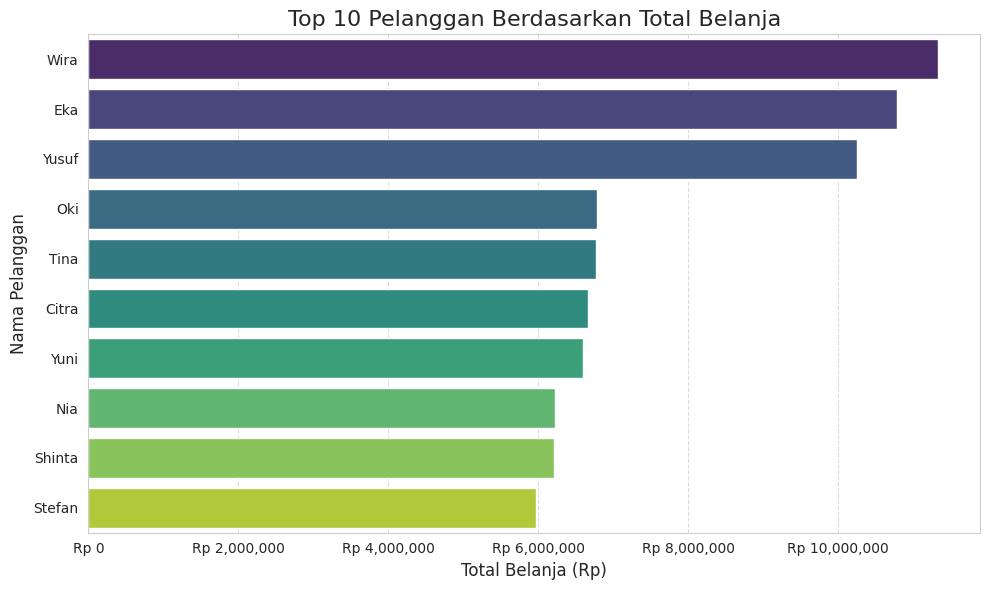

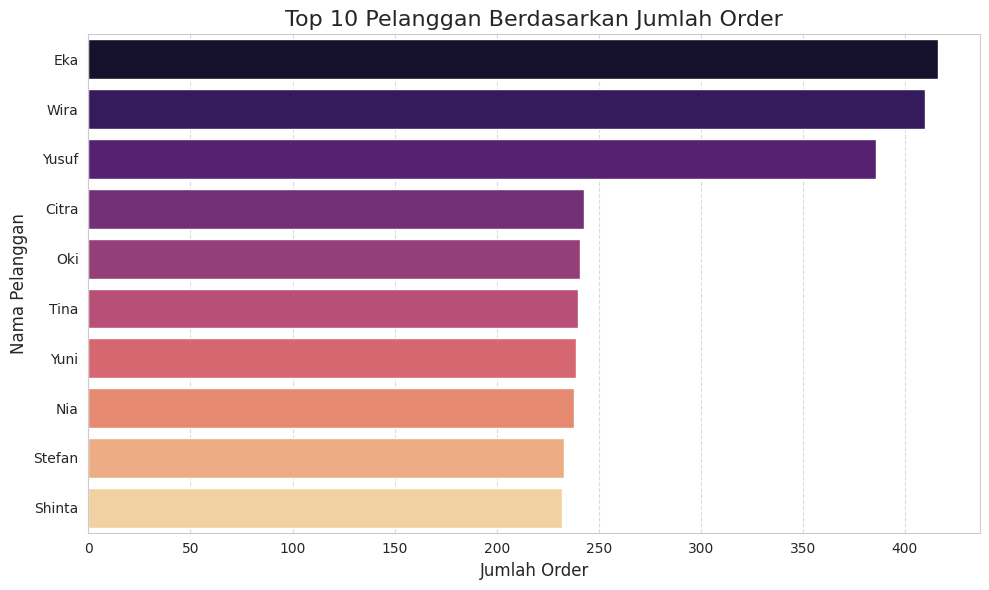

In [65]:
## VISUALISASI TOP CUSTOMER

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# fungsi format rupiah
def rupiah(x, pos):
    return f'Rp {x:,.0f}'

# ==============================
# Chart 1 — Total Spending
# ==============================

plt.figure(figsize=(10,6))

sns.barplot(
    x='total_spending',
    y='customer_name',
    hue='customer_name',
    data=top_customers.sort_values(by='total_spending', ascending=False),
    palette='viridis',
    legend=False
)

plt.title('Top 10 Pelanggan Berdasarkan Total Belanja', fontsize=16)
plt.xlabel('Total Belanja (Rp)', fontsize=12)
plt.ylabel('Nama Pelanggan', fontsize=12)

plt.gca().xaxis.set_major_formatter(FuncFormatter(rupiah))

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==============================
# Chart 2 — Total Orders
# ==============================

plt.figure(figsize=(10,6))

sns.barplot(
    x='total_orders',
    y='customer_name',
    hue='customer_name',
    data=top_customers.sort_values(by='total_orders', ascending=False),
    palette='magma',
    legend=False
)

plt.title('Top 10 Pelanggan Berdasarkan Jumlah Order', fontsize=16)
plt.xlabel('Jumlah Order', fontsize=12)
plt.ylabel('Nama Pelanggan', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

=== TOP KATEGORI PER CHANNEL ===


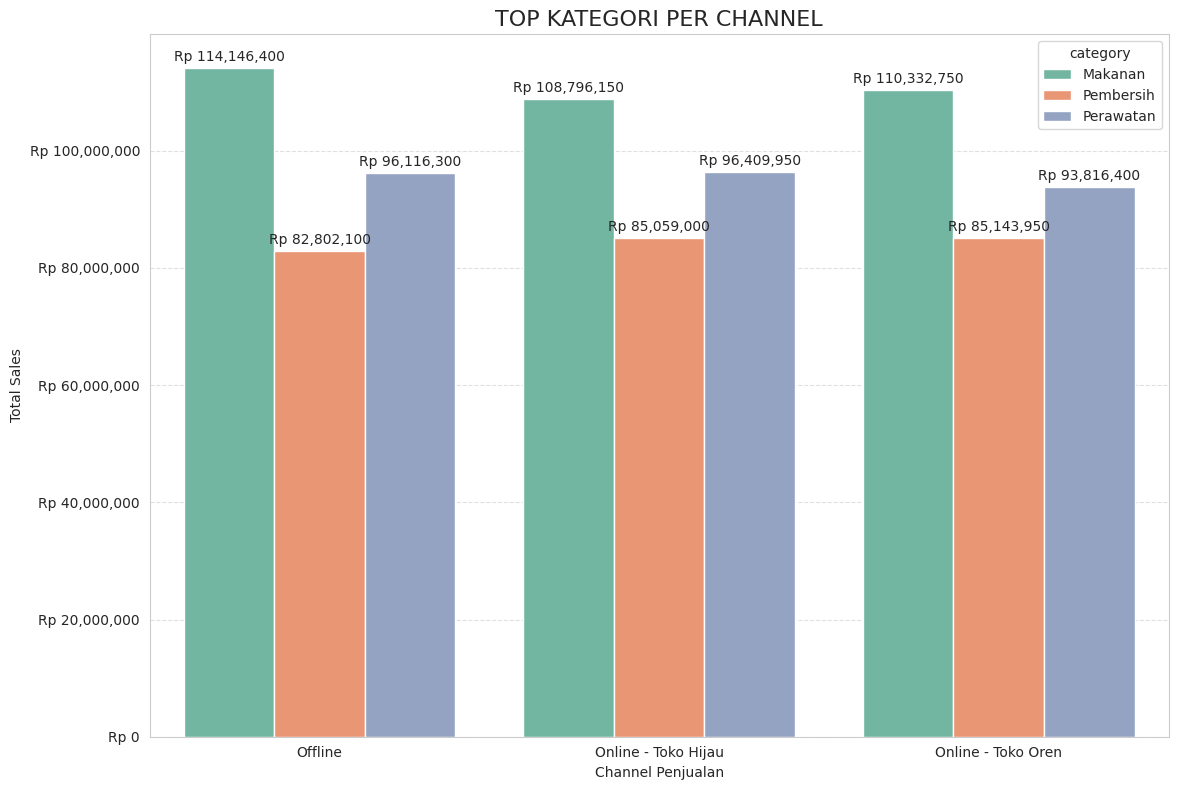

In [66]:
## VISUALISASI TOP KATEGORI PER CHANNEL
print('=== TOP KATEGORI PER CHANNEL ===')

plt.figure(figsize=(11,8))

ax = sns.barplot(
    data=category_channel,
    x='channel',
    y='total_sales',
    hue='category',
    palette='Set2'
)

plt.title('TOP KATEGORI PER CHANNEL', fontsize=16)
plt.xlabel('Channel Penjualan')
plt.ylabel('Total Sales')

# Tambahkan label angka di setiap bar
for container in ax.containers:
    ax.bar_label(container, fmt='Rp {:,.0f}', padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

from matplotlib.ticker import FuncFormatter
def rupiah(x, pos):
    return f'Rp {x:,.0f}'
ax.yaxis.set_major_formatter(FuncFormatter(rupiah))

plt.show()

## 7: EXECUTIVE SUMMARY & BUSINESS INSIGHT

In [67]:
# Q7 Insight
top_customer_name = top_customers.iloc[0]['customer_name']
top_customer_spending = top_customers.iloc[0]['total_spending']
top_customer_orders = top_customers.iloc[0]['total_orders']

# Q8 Insight
top_category_channel = (
    category_channel
    .sort_values(['channel','total_sales'], ascending=[True,False])
    .groupby('channel')
    .first()
    .reset_index()
)

print('══════════════════════════════════════════════════════════════')
print('                📊 EXECUTIVE SUMMARY (Q7 & Q8)               ')
print('══════════════════════════════════════════════════════════════')

print(f'║ Pelanggan Paling Aktif : {top_customer_name:<36} ')
print(f'║ Total Order Pelanggan  : {top_customer_orders:>10} transaksi               ')
print(f'║ Total Belanja          : Rp {top_customer_spending:>18,.0f}        ')

print('══════════════════════════════════════════════════════════════')
print('        Kategori Produk Paling Laris di Tiap Channel         ')
print('══════════════════════════════════════════════════════════════')

for _, row in top_category_channel.iterrows():
    print(f'║ {row["channel"]:<25} → {row["category"]:<20} ')

print('══════════════════════════════════════════════════════════════')

══════════════════════════════════════════════════════════════
                📊 EXECUTIVE SUMMARY (Q7 & Q8)               
══════════════════════════════════════════════════════════════
║ Pelanggan Paling Aktif : Eka                                  
║ Total Order Pelanggan  :        416 transaksi               
║ Total Belanja          : Rp         10,782,000        
══════════════════════════════════════════════════════════════
        Kategori Produk Paling Laris di Tiap Channel         
══════════════════════════════════════════════════════════════
║ Offline                   → Makanan              
║ Online - Toko Hijau       → Makanan              
║ Online - Toko Oren        → Makanan              
══════════════════════════════════════════════════════════════


In [68]:
print('\n╔══════════════════════════════════════════════════════════════╗')
print('║                    💡 BUSINESS INSIGHT                       ║')
print('╠══════════════════════════════════════════════════════════════╣')

print(f'║ • Pelanggan paling aktif adalah {top_customer_name},                         ║')
print(f'║   dengan {top_customer_orders} transaksi dan total belanja                     ║')
print(f'║   sebesar Rp {top_customer_spending:,.0f}. Pelanggan ini                       ║')
print('║   berpotensi menjadi pelanggan loyal dengan kontribusi       ║')
print('║   revenue yang signifikan bagi perusahaan.                   ║')

print('║                                                              ║')
print('║ • Analisis penjualan menunjukkan bahwa kategori produk       ║')
print('║   makanan mendominasi penjualan pada setiap channel.         ║')
print('║   Hal ini menunjukkan adanya preferensi produk yang kuat     ║')
print('║   dari konsumen terhadap kategori tersebut.                  ║')

print('║                                                              ║')
print('║ 🎯 Rekomendasi Strategi:                                     ║')
print('║ • Pertahankan pelanggan aktif melalui program loyalitas      ║')
print('║ • Fokuskan promosi pada kategori produk paling laris         ║')
print('║ • Optimalkan strategi pemasaran pada setiap channel          ║')

print('╚══════════════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════════════╗
║                    💡 BUSINESS INSIGHT                       ║
╠══════════════════════════════════════════════════════════════╣
║ • Pelanggan paling aktif adalah Eka,                         ║
║   dengan 416 transaksi dan total belanja                     ║
║   sebesar Rp 10,782,000. Pelanggan ini                       ║
║   berpotensi menjadi pelanggan loyal dengan kontribusi       ║
║   revenue yang signifikan bagi perusahaan.                   ║
║                                                              ║
║ • Analisis penjualan menunjukkan bahwa kategori produk       ║
║   makanan mendominasi penjualan pada setiap channel.         ║
║   Hal ini menunjukkan adanya preferensi produk yang kuat     ║
║   dari konsumen terhadap kategori tersebut.                  ║
║                                                              ║
║ 🎯 Rekomendasi Strategi:                                     ║
║ • Pertahankan pelanggan 